# Plotting networks with generic coordinates

A pandapower network can be plotted with its geographic coordinates or with generic coordinates that show its topology as an evenly spaced tree.

**Prerequisites**

- pylovo installed with the `notebooks` extra (`uv sync --extra notebooks`) and this notebook running on the kernel of the project environment (`.venv`), see `notebook_tutorials/README.md`.
- A `.env` in the repository root that points to your pylovo database, a completed `pylovo-setup` and generated grids for the postcode area (PLZ) below, e.g. `pylovo-generate --plz 85653`.
- Grids are read for the `VERSION_ID` of `config/config_generation.yaml`.
- `plot_with_generic_coordinates` needs the package `igraph` (part of the `plots` extra).

The stored outputs were generated for the demo postcode area 85653 (Aying), whose buildings, streets and transformers are derived from OpenStreetMap. Map data © OpenStreetMap contributors (ODbL).

In [1]:
# Parameters
plz = 85653  # postcode area with generated grids
kcid = None  # k-means cluster id of the grid; None: first grid of the PLZ
bcid = None  # building cluster id of the grid; None: first grid of the PLZ

## Setup

In [2]:
import warnings

import plotly.io as pio

from pylovo.config_loader import VERSION_ID
from pylovo.database.database_client import DatabaseClient
from pylovo.plotting.generation.networks import (
    draw_tree_network_with_spacing_from_grid_id,
    plot_simple_grid,
    plot_with_generic_coordinates,
)

warnings.filterwarnings("ignore")
# pandapower's plotly functions select the "notebook" renderer, which embeds the complete
# plotly.js (about 4.7 MB) for every figure. The CDN variant keeps this notebook small.
pio.renderers["notebook"] = pio.renderers["notebook_connected"]


In [3]:
dbc = DatabaseClient()  # read-only access (GridGenerator is only needed to generate grids)
cluster_list = dbc.get_list_from_plz(plz)
if not cluster_list:
    raise ValueError(f"No grids of version {VERSION_ID} for PLZ {plz}. Run: pylovo-generate --plz {plz}")
if kcid is None or bcid is None:
    kcid, bcid = cluster_list[0]
print(f"PLZ {plz}, version {VERSION_ID}: {len(cluster_list)} grids; selected kcid={kcid}, bcid={bcid}")

PLZ 85653, version 1: 4 grids; selected kcid=1, bcid=1


The grid with its geographic coordinates, as in the previous notebook:

In [4]:
plot_simple_grid(plz=plz, kcid=kcid, bcid=bcid)

New coordinates can be assigned to the buses and lines to plot them in an evenly spaced, tree-like manner.

## Option 1: plotly
- horizontal alignment
- uses pandapower (generic coordinates computed with igraph) and plotly
- interactive, details are shown when hovering over the buses and lines

In [5]:
plot_with_generic_coordinates(plz=plz, kcid=kcid, bcid=bcid)

## Option 2: networkx
- vertical alignment, root: MV bus
- the pandapower network is converted into a networkx graph, see `3_LV_networkx_graph.ipynb`
- more options to customise the graph

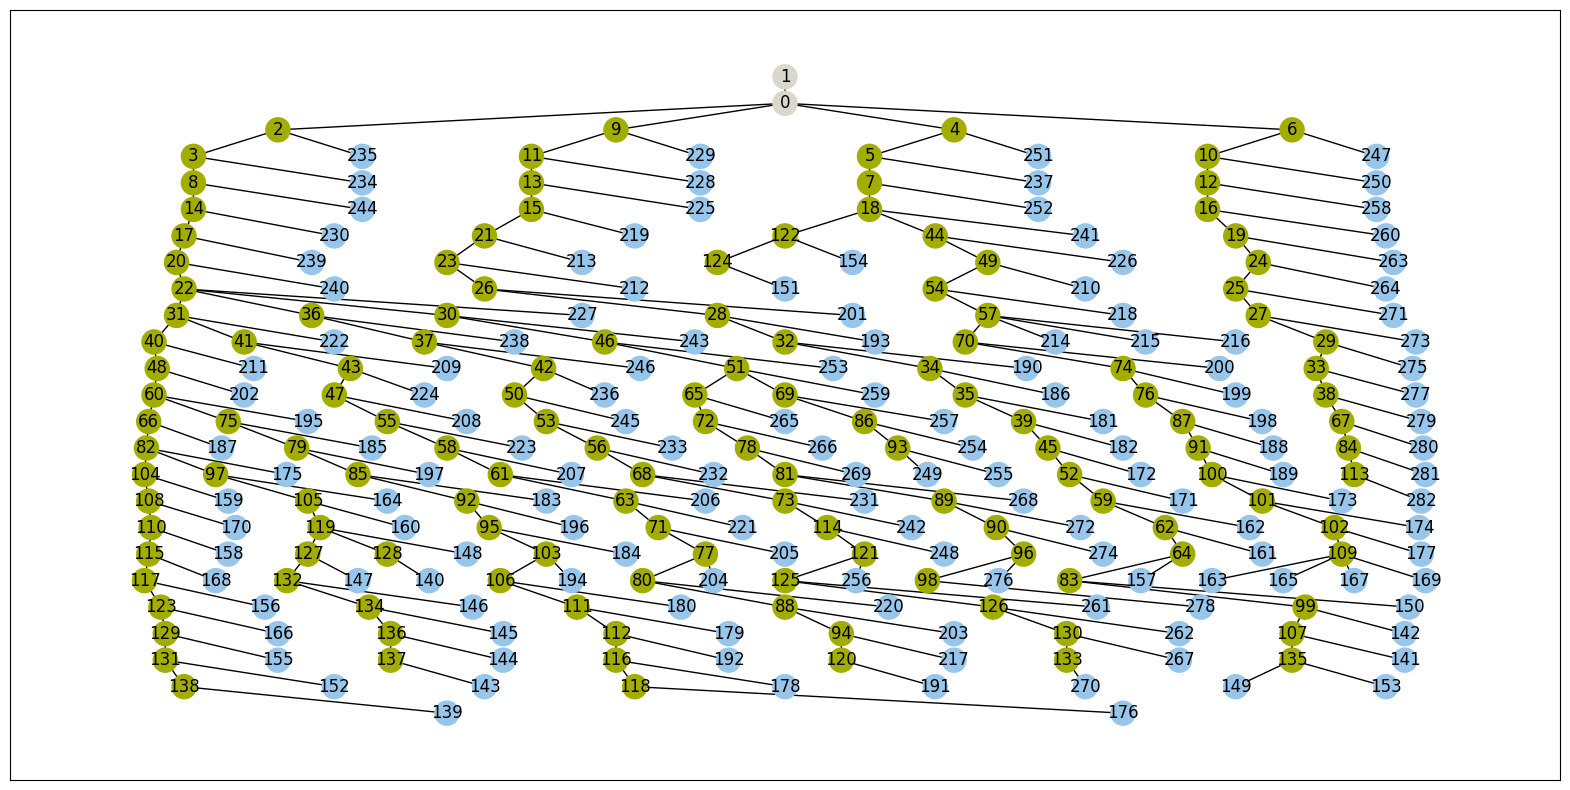

In [6]:
draw_tree_network_with_spacing_from_grid_id(plz=plz, kcid=kcid, bcid=bcid)